In [10]:
#RUN INITIALLY
!pip install ucimlrepo

In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier



In [20]:
seed = 1234
np.random.seed(seed)  

# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets.values.ravel()

# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [34]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=seed, shuffle=True)

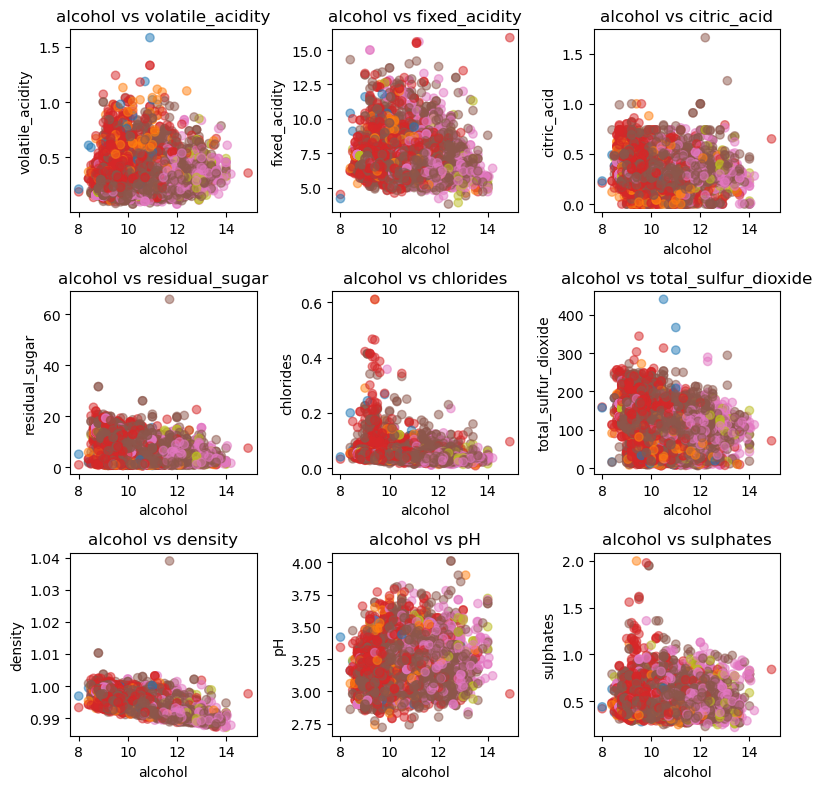

In [22]:
# Make a figure with 9 subplots
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

diff_y = ['volatile_acidity', 'fixed_acidity', 'citric_acid','residual_sugar', 
          'chlorides', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates']

for axes, y_name in zip(axes.flat, diff_y):
    axes.scatter(X['alcohol'], X[y_name], c=y, cmap='tab10', alpha=0.5)
    axes.set_xlabel('alcohol')
    axes.set_ylabel(y_name)
    axes.set_title(f'alcohol vs {y_name}')

plt.tight_layout()
plt.show()


In [15]:
plot_kwargs = {'cmap': 'viridis',
               'response_method': 'predict',
               'plot_method': 'pcolormesh',
               'shading': 'auto',
               'alpha': 0.5,
               'grid_resolution': 100}

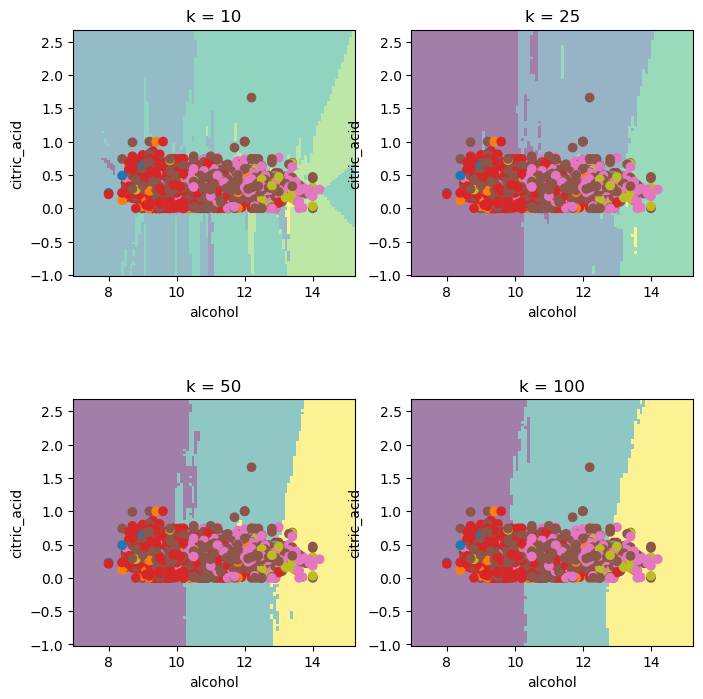

In [23]:
figure, axes = plt.subplots(2, 2, figsize=(8, 8))

### YOUR CODE STARTS HERE ###
plt.subplots_adjust(hspace=0.5)
label_enc = LabelEncoder()
y_vs = label_enc.fit_transform(y_tr)

#looking at alc and chlorides only
X_tr_2 = X_tr[['alcohol','citric_acid']]
X_te_2 = X_te[['alcohol','citric_acid']]

i = 0
for k in [10, 25, 50, 100]:
    knn_class = KNeighborsClassifier(n_neighbors=k)
    knn_class.fit(X_tr_2, y_tr)
    y_pred_tr = knn_class.predict(X_tr_2)
    y_pred_te = knn_class.predict(X_te_2)
    disp = DecisionBoundaryDisplay.from_estimator(knn_class, X_tr_2, 
                                                  ax = axes[i//2, i%2], **plot_kwargs)
    axes[i//2, i%2].scatter(X_tr_2['alcohol'], X_tr_2["citric_acid"],
                            c=y_vs, cmap='tab10')
    axes[i//2, i%2].set_title(f'k = {k}')
    i+=1
    
plt.show()

In [36]:
# feature scaling
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

/opt/miniconda3/envs/cs178/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use 

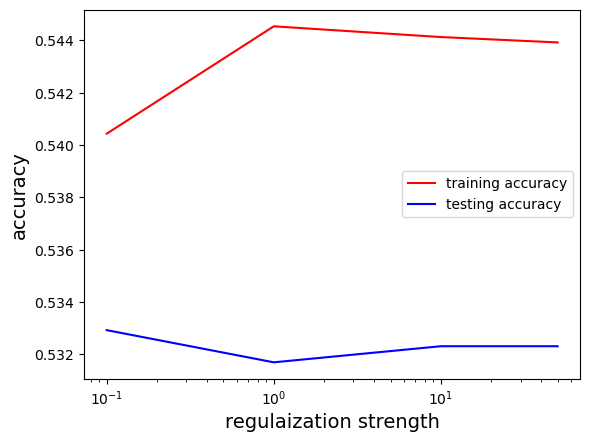

In [37]:
train_accuracies = []
test_accuracies = []
cs = [0.1, 1, 10, 50]

for c in cs:
    classifier = LogisticRegression(penalty='l1', C=c , solver='liblinear', fit_intercept=True)
    classifier.fit(X_tr, y_tr)
    
    # log model training and test accuracies
    train_accuracies.append(accuracy_score(classifier.predict(X_tr), y_tr))
    test_accuracies.append(accuracy_score(classifier.predict(X_te), y_te))

fig, axes = plt.subplots()
axes.semilogx(cs, train_accuracies, color='red', label='training accuracy')
axes.semilogx(cs, test_accuracies, color='blue', label='testing accuracy')

axes.set_xlabel('regulaization strength', fontsize=14)
axes.set_ylabel('accuracy', fontsize=14)

axes.legend()
plt.show()


/opt/miniconda3/envs/cs178/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


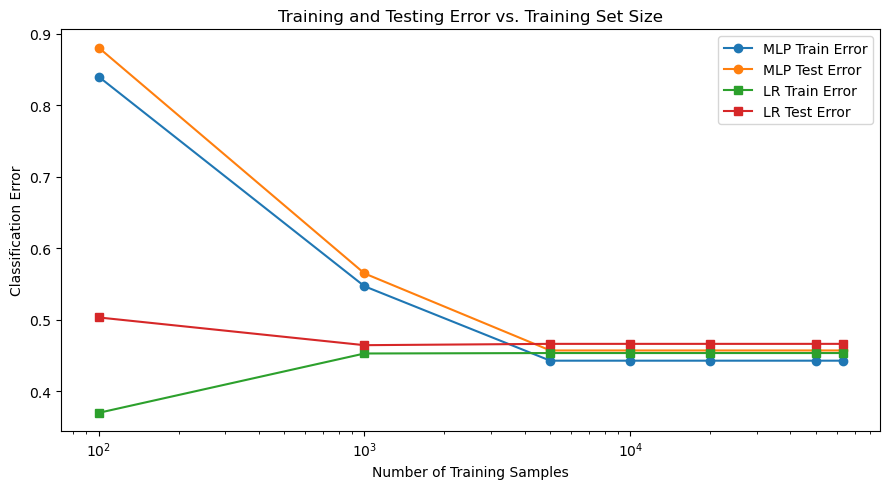

In [48]:
# learning curves w/ neural network
n_tr_values = [100, 1000, 5000, 10000, 20000, 50000, 63000]

mlp_train_errors = []
mlp_test_errors = []
lr_train_errors = []
lr_test_errors = []

for i in n_tr_values:
    X_train_sub = X_tr[:i]
    y_train_sub = y_tr[:i]

    mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                        solver='sgd', learning_rate_init=0.001,
                        batch_size=256, max_iter=1000, early_stopping=True, random_state=seed)
    mlp.fit(X_train_sub, y_train_sub)
    mlp_train_errors.append(1 - mlp.score(X_train_sub, y_train_sub))
    mlp_test_errors.append(1 - mlp.score(X_te, y_te))

    lr = LogisticRegression(random_state=seed)
    lr.fit(X_train_sub, y_train_sub)
    lr_train_errors.append(1 - lr.score(X_train_sub, y_train_sub))
    lr_test_errors.append(1 - lr.score(X_te, y_te))

plt.figure(figsize=(9, 5))
plt.plot(n_tr_values, mlp_train_errors, marker='o', label='MLP Train Error')
plt.plot(n_tr_values, mlp_test_errors, marker='o', label='MLP Test Error')
plt.plot(n_tr_values, lr_train_errors, marker='s', label='LR Train Error')
plt.plot(n_tr_values, lr_test_errors, marker='s', label='LR Test Error')
plt.xscale('log')
plt.xlabel('Number of Training Samples')
plt.ylabel('Classification Error')
plt.title('Training and Testing Error vs. Training Set Size')
plt.legend()
plt.tight_layout()
plt.show()

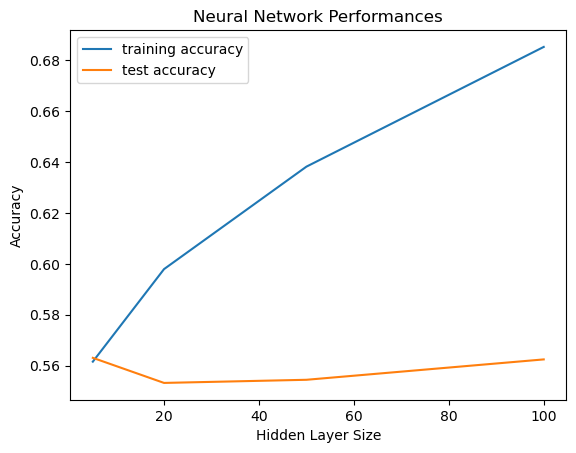

In [45]:
# experiment w/hidden size sweep

hidden_sizes = [5, 20, 50, 100]
train_accs = []
test_accs = []

for h in hidden_sizes:
    nn = MLPClassifier(hidden_layer_sizes=(h,), activation='relu', max_iter=1000, random_state=seed)

    nn.fit(X_tr, y_tr)

    train_acc = accuracy_score(nn.predict(X_tr), y_tr)
    test_acc = accuracy_score(nn.predict(X_te), y_te)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

# plot
plt.plot(hidden_sizes, train_accs, label="training accuracy")
plt.plot(hidden_sizes, test_accs, label="test accuracy")

plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy")
plt.title("Neural Network Performances")
plt.legend()
plt.show()
